# Module 15, Recitation 1

# Interpreting Machine Learning Models Across Modalities  
In this notebook, we explore **how to interpret machine learning models across three major data types**:

### Part 1 — Tabular Data (Adult Income Dataset)
We work with a simplified and highly interpretable subset of the Adult dataset to predict whether someone earns **>50K** per year.  
Using this data, we study:

- **Logistic Regression** → interpretable coefficients  
- **Decision Trees** → transparent rule-based explanations  
- **Random Forests** → feature importance  
- **XGBoost + SHAP** → modern, instance-level and global explanations  

This section highlights the strengths and limitations of classical interpretability tools and how different models “use” numerical and binary features.

---

### Part 2 — Image Interpretability (ResNet50 on ImageNet)
Using a pretrained **ResNet50** and a real dog image, we explore three major interpretability techniques:

- **Saliency Maps**  
  Pixel-level gradients showing which pixels influence the prediction the most.

- **LIME for Images**  
  Region-based explanations using superpixels.

- **Grad-CAM**  
  Heatmaps showing *where the model is looking* inside the image.

These methods give progressively more structured and understandable visual explanations.

---

### Part 3 — Language Interpretability (DistilBERT for Sentiment)
We examine how Transformer-based NLP models make decisions:

- **Attention Maps**  
  Show how words attend to each other during processing.

- **LIME for Text**  
  Identifies which specific words push the prediction positive or negative.

This section highlights how modern language models represent meaning and how local explanations reveal sentiment cues.

---

### Goal of the Recitation
This notebook demonstrates that **interpretability is not a single tool**, but a collection of approaches tailored to:

- the **type of data** (tabular, image, text) and  
- the **model architecture** (linear, tree-based, neural network).

By the end, you'll understand how to read, compare, and critique explanations across modalities.

### Tabular Interpretability: The Adult Income Dataset (Simplified)

In this section, we revisit the **Adult Census Income** dataset, but with a simplified and more interpretable set of features.

The prediction task:
**Does a person earn more than $50K per year? (`income = >50K`)**

Using a curated subset of features, we will train:
- Logistic Regression (coefficients explain global effects)
- Decision Tree (transparent rule-based logic)
- Random Forest (feature importance)
- SHAP (modern global/local explanations)

This reduced feature set dramatically improves interpretability while keeping the model informative.


### 1.1 Load Dataset & Dependencies

In [12]:
!pip install -q shap xgboost pandas scikit-learn

import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

### 1.2 Load the Adult Dataset


In [13]:
import pandas as pd

adult = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=[
        "age","workclass","fnlwgt","education","education-num",
        "marital-status","occupation","relationship","race","sex",
        "capital-gain","capital-loss","hours-per-week","native-country",
        "income"
    ],
    na_values="?"
)

adult = adult.dropna()

# Simplified interpretable features
features = [
    "age",
    "sex",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
    "marital-status",
]

df = adult[features + ["income"]].copy()

# Binary encode income
df["income"] = (df["income"] == " >50K").astype(int)

# Simplify sex
df["sex"] = (df["sex"] == " Male").astype(int)

# Simplify marital-status to Married vs Not-Married
df["marital-status"] = df["marital-status"].apply(
    lambda x: 1 if "Married" in x else 0
)

df.head()


,age,sex,education-num,hours-per-week,capital-gain,capital-loss,marital-status,income
0,39,1,13,40,2174,0,0,0
1,50,1,13,13,0,0,1,0
2,38,1,9,40,0,0,0,0
3,53,1,7,40,0,0,1,0
4,28,0,13,40,0,0,1,0


#### Understanding the Simplified Adult Income Dataset

To make the Adult dataset easier to interpret, we focus on a **small set of intuitive, meaningful features** that strongly relate to income. This avoids the complexity of many categorical variables and produces clearer explanations, better logistic regression coefficients, and more interpretable decision trees.

Below are the features we use and what each one represents.

---

### **Demographic & Personal Attributes**

| Feature | Meaning | Why it's intuitive |
|---------|---------|---------------------|
| **age** | Age of the individual in years. | Income tends to increase with age until mid-career, then flatten. |
| **sex** | Encoded as 1 = male, 0 = female. | Helps explore gender differences in income distribution. |
| **marital-status** | Simplified to **1 = married**, **0 = not married**. | Married individuals often have more financial stability and may work more years. |

---

### **Education & Skill Indicators**

| Feature | Meaning | Why it's intuitive |
|---------|---------|---------------------|
| **education-num** | A numeric score representing highest education level (e.g., HS-grad = 9, Bachelors = 13). | Education is one of the strongest predictors of income. |

---

### **Work & Financial Attributes**

| Feature | Meaning | Why it's intuitive |
|---------|---------|---------------------|
| **hours-per-week** | Average number of hours worked per week. | More working hours often correlate with higher income. |
| **capital-gain** | Investment gains (e.g., stocks, real estate). Usually zero for most people. | A direct signal of financial wealth; large values strongly predict high income. |
| **capital-loss** | Investment losses used for tax purposes. | Lower predictive power than gains but still indicates participation in financial markets. |

---

### **Target Variable**

| Feature | Meaning |
|---------|---------|
| **income** | Binary label: **1 = income > \$50K**, **0 = income ≤ \$50K**. |

---

### Why these features?

This reduced feature set was chosen because:

- Each variable is **numerical or binary**, so no complex encoding is needed.  
- All features are **intuitive to interpret** (age, education, working hours).  
- They create **clean and meaningful decision trees**.  
- Logistic regression coefficients become easier to explain and visualize.  
- SHAP values highlight recognizable socioeconomic patterns.  

By simplifying the dataset, we preserve its real-world relevance while making the explainability techniques much more effective for teaching.


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define your simplified feature groups
num_cols = ["age", "education-num", "hours-per-week", "capital-gain", "capital-loss"]
cat_cols = ["sex", "marital-status"]   # already binary, but kept for generality

# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols),
    ],
    remainder="drop"  # keep only the columns we explicitly listed
)



### 1.4 Logistic Regression

Logistic Regression is a transparent linear model.
- Positive coefficient → increases probability of >50K  
- Negative coefficient → decreases it  


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logreg = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

logreg.fit(X_train, y_train)

feature_names = logreg.named_steps["preprocess"].get_feature_names_out()
feature_names



array(['num__age', 'num__education-num', 'num__hours-per-week',
       'num__capital-gain', 'num__capital-loss', 'cat__sex',
       'cat__marital-status'], dtype=object)

### 1.5 Coefficient Interpretation

We extract the encoded feature names and match them to the learned weights.
This gives a global explanation of what the model considers important.


In [16]:
# Get final feature names directly from the preprocessor
feature_names = logreg["preprocess"].get_feature_names_out()

# Extract coefficients
coeffs = logreg.named_steps["clf"].coef_[0]

# Build dataframe
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coeffs
})

coef_df.sort_values("coef", ascending=False).head(10)


,feature,coef
6,cat__marital-status,2.331543
3,num__capital-gain,2.256948
1,num__education-num,0.927022
2,num__hours-per-week,0.388871
0,num__age,0.373053
4,num__capital-loss,0.265035
5,cat__sex,0.168646


### 1.6 Decision Tree Model

Decision Trees yield **logical rules** that are easy to visualize.
We limit max depth to keep the tree understandable.


In [17]:
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", "passthrough", cat_cols)
    ]
)


tree = Pipeline([
    ("preprocess", preprocess_tree),
    ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=200 ,random_state=42))
])
tree.fit(X_train, y_train);


### 1.7 Decision Tree Visualization

Each split corresponds to a rule:
- IF feature < threshold → go left  
- ELSE → go right  

Leaf nodes represent predictions.


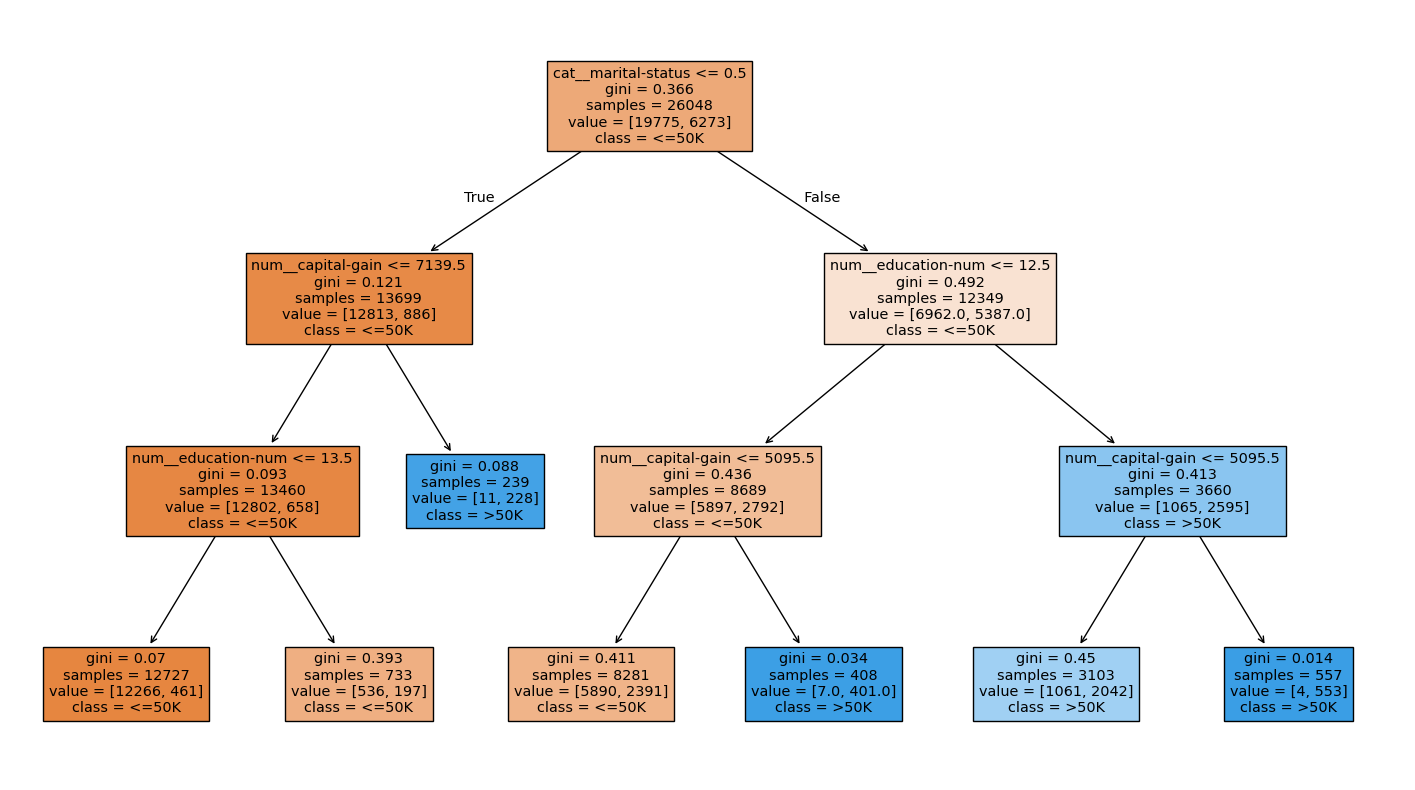

In [18]:

plt.figure(figsize=(18, 10))
plot_tree(
    tree.named_steps["clf"],
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True
)
plt.show()


### 1.8 Explaining a Single Decision Path

Trees allow us to inspect *exactly* how a prediction was made.
We show the sequence of splits used for one test example.


In [19]:
sample = X_test.iloc[[0]]
sample_trans = tree.named_steps["preprocess"].transform(sample)

node_indicator = tree.named_steps["clf"].decision_path(sample_trans)
node_indicator.indices


array([0, 1, 2, 4], dtype=int32)

### 1.9 Ensembles: RF & XGBoost

Ensemble models are more accurate but harder to interpret.
We start by training them.


In [22]:
rf = Pipeline([
    ("preprocess", preprocess_tree),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])
rf.fit(X_train, y_train)

xgb_model = Pipeline([
    ("preprocess", preprocess_tree),
    ("clf", xgb.XGBClassifier(n_estimators=300, max_depth=5, random_state=42))
])
xgb_model.fit(X_train, y_train);


### 1.10 Feature Importances

Feature importance ranks variables according to how useful they are for prediction.
This is a **global** explanation, describing model behavior across all samples.

#### Random Forest Feature Importance

Random Forests consist of many decision trees.  
Each tree repeatedly *splits* the data based on different features.  
A split is considered “good” if it reduces impurity — meaning it helps separate the classes more cleanly.

#### How Random Forest feature importance is computed
For each feature:
1. Every time the feature is used in a split, compute how much the split reduces impurity.
2. Sum these impurity reductions across all trees.
3. Normalize the values so they add up to 1.

This results in **Mean Decrease in Impurity (MDI)**, also called **Gini importance**.



In [23]:
importances = rf.named_steps["clf"].feature_importances_
pd.DataFrame({"feature": feature_names, "importance": importances}) \
    .sort_values("importance", ascending=False).head(10)


,feature,importance
0,num__age,0.249923
6,cat__marital-status,0.185454
1,num__education-num,0.173999
3,num__capital-gain,0.165119
2,num__hours-per-week,0.145697
4,num__capital-loss,0.058210
5,cat__sex,0.021598


### 1.11 SHAP Values

SHAP (SHapley Additive exPlanations) assigns each feature a value representing how much it contributes to a given prediction.

SHAP values come from cooperative game theory, treating each feature as a “player” contributing to the model’s output.

### 🔹 Intuition: How SHAP values are computed
For each feature:
- Consider all possible combinations of other features.
- Ask how much adding the feature changes the prediction.
- Average this contribution across all combinations.

This produces a **fair, consistent measure** of feature influence.

For tree-based models (Random Forest, XGBoost), SHAP uses a fast exact algorithm.

### 🔹 How to read the SHAP beeswarm plot
Each dot is a single person in the dataset.

- **Y-axis:** Features sorted by importance.
- **X-axis:** SHAP value  
  - Positive → pushes the model toward predicting the positive class (>50K income)  
  - Negative → pushes toward the negative class (≤50K income)

- **Color:** Original feature value  
  - **Red = high value**  
  - **Blue = low value**

### 🔹 What SHAP reveals
- Which features matter most (global explanation)
- Whether a high or low value increases/decreases income prediction
- How features interact differently for different individuals

### 🔹 SHAP vs Random Forest Feature Importance

| Method | What it tells you | What it *doesn’t* tell you |
|--------|------------------|-----------------------------|
| **Random Forest Importance** | Which features reduce impurity | Direction or individualized impact |
| **SHAP Values** | How each feature pushes predictions up/down | — (SHAP is fully local + global) |

SHAP provides both *global understanding* and *instance-level explanations*, making it one of the most powerful interpretability tools available today.



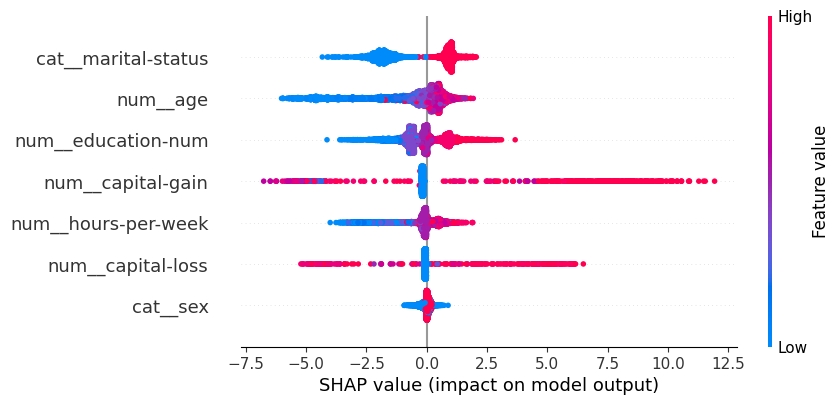

In [24]:
import shap

# Extract trained booster
booster = xgb_model.named_steps["clf"]

# Get feature names *after preprocessing*
feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()

# Transform full test set
X_test_transformed = xgb_model.named_steps["preprocess"].transform(X_test)

# Create SHAP explainer with correct feature names
explainer = shap.TreeExplainer(booster)

# Compute SHAP values for ALL samples
shap_values = explainer(X_test_transformed)

# Assign feature names for plotting
shap_values.feature_names = feature_names

# Beeswarm plot with real feature names
shap.plots.beeswarm(shap_values)


## Section 2 — Image Interpretability

Deep learning models for images (like CNNs) learn patterns such as edges, textures, colors, and object shapes.  
But even though they achieve high accuracy, it is not always obvious **why** a CNN makes a particular prediction.

In this section, we explore three widely used interpretability techniques for vision models.  
Each one gives us a different way to understand **what parts of an image influence the model’s decision.**

---

### **1. Saliency Maps** — “Which pixels matter most?”

Saliency maps highlight the pixels that the model is most sensitive to.  
They work by computing the **gradient** of the model’s output with respect to each pixel.

- Bright areas = small pixel changes strongly affect the prediction  
- Dark areas = little influence  

This method is simple and fast, but also noisy.  
It gives us a *first-glance intuition* about which parts of the image the model depends on.

---

### **2. LIME for Images** — “What regions (superpixels) matter?”

LIME (Local Interpretable Model-Agnostic Explanations) explains a single prediction by:

1. Breaking the image into **superpixels** (small connected regions).
2. Randomly hiding or masking these regions.
3. Seeing how the prediction changes when regions disappear.
4. Fitting a simple surrogate model to identify which regions were important.

LIME answers the question:

> **If I remove this region, does the prediction change significantly?**

This produces an intuitive heatmap of **important image regions**, rather than individual pixels.

---

### **3. Grad-CAM** — “Where does the CNN look?”

Grad-CAM (Gradient-weighted Class Activation Mapping) is one of the most powerful and intuitive vision interpretability tools.

It uses the **final convolutional feature maps** and their gradients to identify:

- *Which spatial locations* contribute most to the predicted class  
- *Which regions the model attends to* when making a decision  

The result is a **localized heatmap** that can be overlayed on the original image.

Example interpretations:

- Bright red regions = high importance  
- Blue/transparent regions = low importance  

Grad-CAM is particularly good at showing *object parts* (e.g., the head of a dog, the outline of a cat, etc.).

---

### Example

In this section, we use a pre-trained **ResNet50** model (trained on ImageNet) to classify a clean dog image.  
This lets us visualize how a state-of-the-art CNN reasons about natural images.

Together, these methods help us understand model behavior from **three perspectives**:

- **Saliency** → individual pixels  
- **LIME** → meaningful regions (superpixels)  
- **Grad-CAM** → the model’s high-level spatial attention  

Understanding these tools is essential for detecting bias, debugging models, and building trustworthy AI systems.


### 2.1 Load libraries and dog image

In [12]:
import torch
from torchvision import models, transforms
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import cv2
import requests
from io import BytesIO


### 2.2 Load pretrained ResNet50

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
imagenet_model = models.resnet50(weights="IMAGENET1K_V2")
imagenet_model = imagenet_model.to(device)
imagenet_model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### 2.3 Download image

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

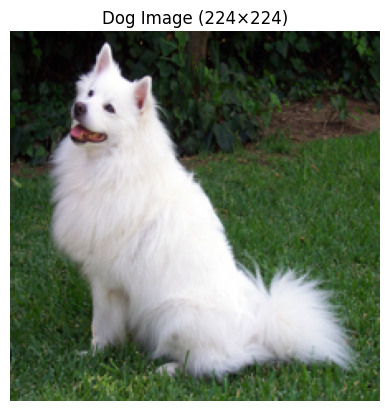

In [14]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img_pil = Image.open(BytesIO(response.content)).convert("RGB")
# Downscale explicitly to match ResNet input size
img_resized = img_pil.resize((224, 224))

# Convert to numpy for visualization
img_np = np.array(img_resized)

plt.imshow(img_np)
plt.title("Dog Image (224×224)")
plt.axis("off")


### 2.4 Preprocess

In [15]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),      # works on PIL Images
    transforms.ToTensor(),              # converts to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# img_pil = Image.fromarray(img_np)
img_tensor = preprocess(img_pil).unsqueeze(0).to(device)


### 2.5 Predict

In [16]:
with torch.no_grad():
    logits = imagenet_model(img_tensor)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

pred_class = probs.argmax()
pred_class


np.int64(258)

### 2.6 Compute saliency map

In [17]:
img_tensor.requires_grad = True
output = imagenet_model(img_tensor)

score = output[0, pred_class]
imagenet_model.zero_grad()
score.backward()

saliency = img_tensor.grad.data.abs().max(dim=1)[0].cpu().numpy()[0]
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())


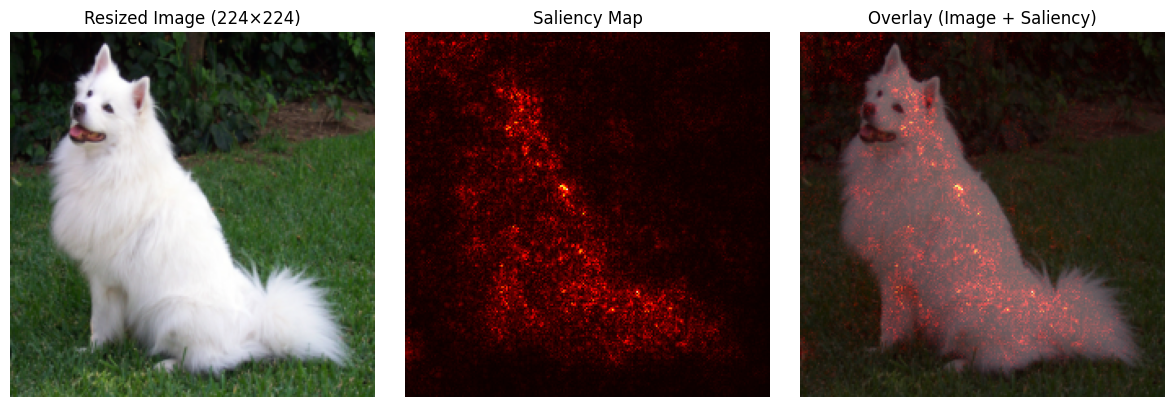

In [18]:
# 1) Show the resized image that the model actually sees
img_resized = preprocess.transforms[0](img_pil)   # Resize only, remove Normalize+ToTensor
img_resized_np = np.array(img_resized)

# 2) Create overlay (heatmap on resized image)
heatmap = plt.cm.hot(saliency)[..., :3]        # RGB heatmap
overlay = 0.6 * heatmap + 0.4 * (img_resized_np / 255.0)

# ---- Plot side-by-side ----
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Resized Image (224×224)")
plt.imshow(img_resized_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Saliency Map")
plt.imshow(saliency, cmap="hot")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay (Image + Saliency)")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()


### 2.7 Lime explanation

In [19]:
!pip install lime

  0%|          | 0/1000 [00:00<?, ?it/s]

Using LIME label: 258


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

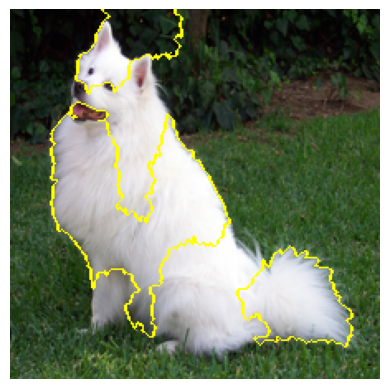

In [20]:
# LIME imports
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Create explainer
explainer = lime_image.LimeImageExplainer()

def lime_predict(images):
    tensors = []
    for img in images:
        arr = (img * 255).astype(np.uint8)   # float → uint8
        pil = Image.fromarray(arr)           # ndarray → PIL
        t = preprocess(pil)                  # PIL → tensor
        tensors.append(t)

    batch = torch.stack(tensors).to(device)
    with torch.no_grad():
        logits = imagenet_model(batch)
        probs = torch.softmax(logits, dim=1)

    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    np.array(img_np)/255.0,
    lime_predict,
    top_labels=1,
    num_samples=1000
)

lime_label = list(explanation.local_exp.keys())[0]  # first (and top) explained label
print("Using LIME label:", lime_label)

temp, mask = explanation.get_image_and_mask(
    lime_label,
    positive_only=True,
    num_features=5,
    hide_rest=False
)


plt.imshow(mark_boundaries(temp, mask))
plt.axis("off")


### 2.8 Implement Grad-CAM

In [21]:
gradients = []
activations = []

def forward_hook(module, inp, out):
    activations.append(out)

def backward_hook(module, gin, gout):
    gradients.append(gout[0])

target_layer = imagenet_model.layer4
fwd = target_layer.register_forward_hook(forward_hook)
bwd = target_layer.register_backward_hook(backward_hook)

def grad_cam(model, img_tensor, class_idx):
    gradients.clear()
    activations.clear()

    output = model(img_tensor)
    score = output[0, class_idx]
    model.zero_grad()
    score.backward()

    acts = activations[-1].detach().cpu().numpy()[0]
    grads = gradients[-1].detach().cpu().numpy()[0]

    weights = grads.mean(axis=(1,2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i,w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam,0)
    cam /= cam.max()
    return cam


### 2.9 Visualize GradCAM

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Text(0.5, 1.0, 'Overlay')

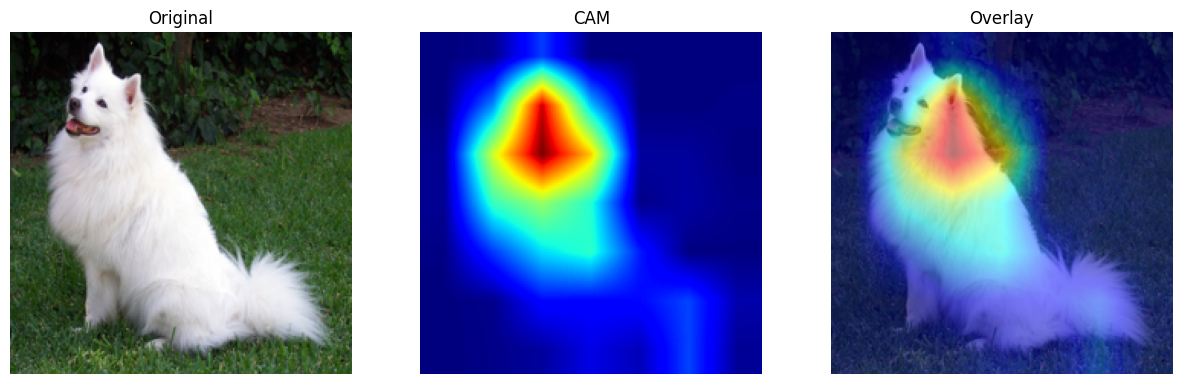

In [22]:
cam = grad_cam(imagenet_model, img_tensor, pred_class)
cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
overlay = (0.5*img_np + 0.5*heatmap).astype(np.uint8)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img_np); plt.axis("off"); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(cam_resized,cmap="jet"); plt.axis("off"); plt.title("CAM")
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis("off"); plt.title("Overlay")


## Section 3 — Language Interpretability

Transformer models use attention to determine how words influence each other.

We will demonstrate:
- Tokenization with BERT  
- Attention heatmaps  
- LIME for text  

Model: DistilBERT fine-tuned on sentiment classification.


### 3.1 Load model

In [23]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F
import seaborn as sns

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
nlp_model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)
nlp_model.to(device)
nlp_model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

### 3.2 Run example sentence

In [24]:
sentence = "I absolutely loved the cinematography, but the plot was terrible."

inputs = tokenizer(sentence, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = nlp_model(**inputs)

probs = F.softmax(outputs.logits, dim=1)
attentions = outputs.attentions  # list of attention matrices
probs


tensor([[0.9948, 0.0052]], device='cuda:0')

### 3.3 Attention Heatmap

An attention matrix tells us **how much each word attends to every other word** in the sentence.

- Each row represents a word *querying* information.
- Each column represents a word it might *pay attention to*.
- Brighter values mean the model considers that connection more important when building the meaning of the sentence.

This helps us see which words the model links together and which parts of the sentence it uses to form its final representation.


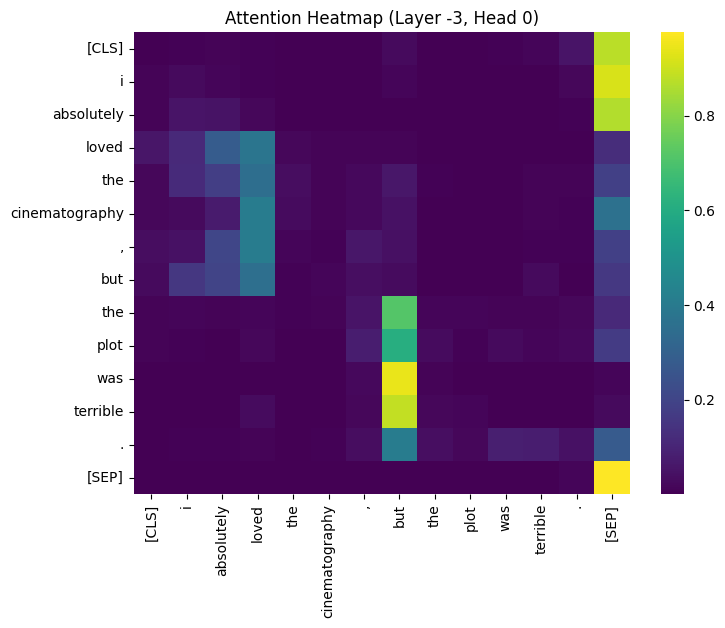

In [28]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

att = attentions[-3][0][0].cpu().detach().numpy()  # (seq_len, seq_len)

plt.figure(figsize=(8,6))
sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Heatmap (Layer -3, Head 0)")
plt.show()


### 3.5 LIME for text

LIME explains a model’s prediction by asking a simple question:

**“Which words change the prediction if we remove or alter them?”**

To answer this, LIME:

1. **Creates many perturbed versions of the sentence**  
   - Words are randomly removed or masked.  
   - Example:  
     - "I absolutely loved the cinematography, but the plot was terrible."  
     - → remove "terrible"  
     - → remove "loved"  
     - → remove "absolutely"  
     - → remove both "but" and "terrible", etc.

2. **Runs the model on these modified sentences**  
   - LIME checks how the prediction probability changes.

3. **Fits a simple, interpretable model** (like linear regression)  
   - The input is: which words were kept or removed  
   - The output is: how the prediction changed  
   - The coefficients of this simple model tell us **which words push the prediction positive or negative**.

4. **Displays word contributions**  
   - Positive words (pushing toward "positive sentiment") are shown in orange.  
   - Negative words (pushing toward "negative sentiment") are shown in blue.  
   - The size of the bar shows *how strong* the contribution is.

LIME therefore provides a **local explanation**:  
It tells us *which specific words caused this specific prediction*.

In [29]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=["negative","positive"])

def predict_proba_text(texts):
    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = nlp_model(**tokens).logits
    return F.softmax(logits, dim=1).cpu().detach().numpy()

exp = explainer.explain_instance(sentence, predict_proba_text, num_features=8)
exp.show_in_notebook()


Sentence:
> **“I absolutely loved the cinematography, but the plot was terrible.”**

Your model predicted **negative** sentiment with very high confidence (0.99).

LIME highlights:

- **Negative contributors** (blue):  
  - *terrible* — very strong negative word  
  - *but* — signals a contrast, often introducing criticism  
  - smaller contributions from “was” and “plot”

- **Positive contributors** (orange):  
  - *loved* — strong positive word  
  - *absolutely* — intensifier  
  - *cinematography* — neutral but used in a positive context here

This reflects natural language behavior:

- The phrase **"but the plot was terrible"** overrides the earlier praise.  
- Even though the movie had aspects the speaker liked,  
  **LIME correctly shows that “terrible” dominates the sentiment prediction.**

This is an excellent example of how LIME reveals:
- not just which words matter,  
- but **how the model balances conflicting signals within a sentence.**


## Key Takeaways

### 1. Different data types need different interpretability tools  
- **Tabular:** coefficients, trees, SHAP  
- **Images:** saliency, LIME, Grad-CAM  
- **Text:** attention maps, LIME  

### 2. Linear and tree models are easy to interpret  
- Logistic Regression → direction + strength of effects  
- Decision Trees → human-readable rules  
- Ensembles → better accuracy, need SHAP for explanations  

### 3. SHAP provides rich global + local insights  
SHAP shows both how important a feature is **overall** and how it affects **individual predictions**.

### 4. Image methods provide different levels of detail  
- Saliency → pixel sensitivity  
- LIME → important regions  
- Grad-CAM → where the model “looks”  

### 5. NLP explanations show relationships and influence  
- Attention = word-to-word interactions  
- LIME = which specific words drive the prediction  

### 6. Interpretability is essential for debugging and trust  
Explanations help detect bias, incorrect model behavior, and dataset quirks.
